In [1]:
!pip -q install "transformers>=4.51,<4.58" "accelerate>=0.30,<1.0" "pillow>=10,<12" matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

c:\Users\bhara\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.9.0+cpu
CUDA available: False
Device: cpu


## Project Paths

This cell works both locally and in Colab. It is configured for `data/pixmo_subset_v3`. If auto-detection fails, set `PROJECT_ROOT` manually.

In [5]:
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/drive/MyDrive/Grasp Point Prediction"),
    Path("/content/drive/MyDrive/eng521/Grasp Point Prediction"),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "data" / "pixmo_subset_v3").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root. Set PROJECT_ROOT manually in this cell."
    )

DATASET_NAME = "pixmo_subset_v3"
DATA_ROOT = PROJECT_ROOT / "data" / DATASET_NAME
# handle nested layout where the dataset folder contains a single inner folder
# e.g., data/pixmo_subset_v3/pixmo_subset_v3/
if DATA_ROOT.exists() and not (DATA_ROOT / "metadata.json").exists():
    for child in sorted(DATA_ROOT.iterdir()):
        if child.is_dir() and (child / "metadata.json").exists():
            DATA_ROOT = child
            break

SPLITS_DIR = DATA_ROOT / "splits"
IMAGES_DIR = DATA_ROOT / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "grounding_dino_from_scratch"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_NAME:", DATASET_NAME)
print("DATA_ROOT:", DATA_ROOT)
print("SPLITS_DIR exists:", SPLITS_DIR.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction
DATASET_NAME: pixmo_subset_v3
DATA_ROOT: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\data\pixmo_subset_v3\pixmo_subset_v3
SPLITS_DIR exists: True
IMAGES_DIR exists: True
OUTPUT_DIR: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch


In [31]:
# Quick stats: total samples and split sizes (train/val/test)
import json
from collections import Counter

if 'DATA_ROOT' not in globals():
    raise RuntimeError('DATA_ROOT is not defined — run the Project Paths cell first')

meta_path = DATA_ROOT / 'metadata.json'
if not meta_path.exists():
    raise FileNotFoundError(f'Metadata not found: {meta_path}')

with open(meta_path, 'r', encoding='utf-8') as f:
    full_meta = json.load(f)

total_samples = len(full_meta)
unique_labels = sorted({r.get('label') for r in full_meta})
label_counts = Counter(r.get('label') for r in full_meta)
images_count = len(list((DATA_ROOT / 'images').glob('*.*')))
pointing_overall = sum(1 for r in full_meta if r.get('collection_method') == 'pointing')

split_counts = {}
for split_name in ['train', 'val', 'test']:
    p = SPLITS_DIR / f'{split_name}.json'
    if p.exists():
        with open(p, 'r', encoding='utf-8') as sf:
            d = json.load(sf)
        split_counts[split_name] = len(d)
    else:
        split_counts[split_name] = None

print('Dataset root:', DATA_ROOT)
print('Total metadata entries:', total_samples)
print('Images in images/ folder:', images_count)
print('Unique labels:', len(unique_labels))
print('Pointing samples overall:', pointing_overall)
print('Split sizes:', split_counts)
print('Top label counts (10):', label_counts.most_common(10))


Dataset root: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\data\pixmo_subset_v3\pixmo_subset_v3
Total metadata entries: 914
Images in images/ folder: 914
Unique labels: 48
Pointing samples overall: 914
Split sizes: {'train': 548, 'val': 183, 'test': 183}
Top label counts (10): [('backpack', 20), ('bag', 20), ('calculator', 20), ('charger', 20), ('headphones', 20), ('jar', 20), ('kettle', 20), ('keyboard', 20), ('laptop', 20), ('mouse', 20)]


In [29]:
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Expected dataset folder not found: {DATA_ROOT}")

metadata_path = DATA_ROOT / "metadata.json"
print("Using dataset folder:", DATA_ROOT)
print("Metadata file exists:", metadata_path.exists())

if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print("Metadata preview:")
    print(json.dumps(metadata, indent=2)[:1000])

Using dataset folder: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\data\pixmo_subset_v3\pixmo_subset_v3
Metadata file exists: True
Metadata preview:
[
  {
    "id": 0,
    "label": "backpack",
    "collection_method": "pointing",
    "count": null,
    "points": [
      {
        "x": 74.1666603693891,
        "y": 56.026233491443456
      }
    ],
    "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/backpack_1.jpg",
    "image_url": "http://www.andes.org.uk/peak-info-6000/famatina-summit.jpg"
  },
  {
    "id": 1,
    "label": "backpack",
    "collection_method": "pointing",
    "count": null,
    "points": [
      {
        "x": 60.88331997284503,
        "y": 50.31865618565404
      }
    ],
    "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/backpack_2.jpg",
    "image_url": "https://i.dailymail.co.uk/1s/2020/08/16/13/31998746-8631821-With_his_Proud_

## Load One Split

In [7]:
SPLIT_NAME = "val"  # validation split for prompt selection
SPLIT_PATH = SPLITS_DIR / f"{SPLIT_NAME}.json"

with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split_data = json.load(f)

print("Loaded split:", SPLIT_NAME)
print("Number of rows:", len(split_data))
print("Available keys:", sorted(split_data[0].keys()))
print("Example row:\n")
print(json.dumps(split_data[0], indent=2)[:2000])

Loaded split: val
Number of rows: 183
Available keys: ['collection_method', 'count', 'id', 'image_path', 'image_url', 'label', 'points']
Example row:

{
  "id": 403,
  "label": "apple",
  "collection_method": "pointing",
  "count": null,
  "points": [
    {
      "x": 54.82142857142858,
      "y": 43.214285714285715
    }
  ],
  "image_path": "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3/images/apple_2.jpg",
  "image_url": "https://img.freepik.com/premium-vector/food-basket-flat-vector-illustration-food-basket-hand-drawing-isolated-vector-illustration_501705-688.jpg"
}


In [8]:
labels_in_split = sorted({row["label"] for row in split_data})
print("Unique labels in split:", len(labels_in_split))
print(labels_in_split)

Unique labels in split: 26
['backpack', 'book', 'bottle', 'calculator', 'charger', 'fork', 'headphones', 'highlighter', 'jar', 'kettle', 'keyboard', 'knife', 'marker', 'mouse', 'mug', 'pen', 'phone', 'plate', 'scissor', 'shoe', 'spoon', 'stapler', 'toothbrush', 'umbrella', 'wallet', 'watch']


In [8]:
pointing_samples = [
    row for row in split_data
    if row.get("collection_method") == "pointing"
]

print("Pointing samples:", len(pointing_samples))
print("First pointing sample id:", pointing_samples[0]["id"] if pointing_samples else None)

Pointing samples: 183
First pointing sample id: 403


## Inspect One Example

Label: apple
Filename: apple_2.jpg
Image path: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\data\pixmo_subset_v3\pixmo_subset_v3\images\apple_2.jpg
Point count: 1


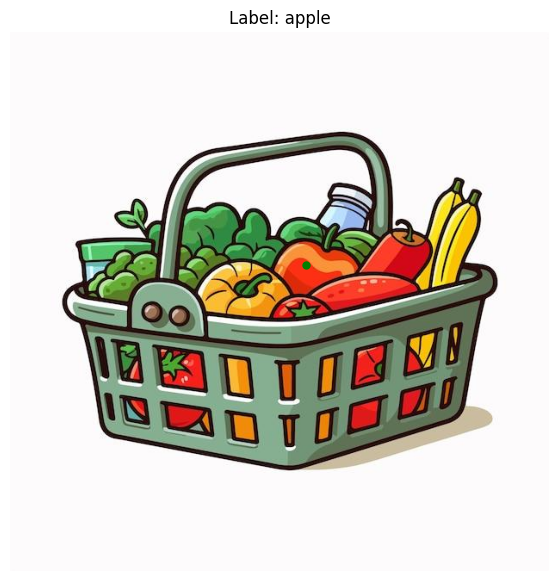

In [9]:
sample = pointing_samples[0]
label = sample["label"]
points = sample["points"]
filename = os.path.basename(sample["image_path"])
image_path = IMAGES_DIR / filename

print("Label:", label)
print("Filename:", filename)
print("Image path:", image_path)
print("Point count:", len(points))

image = Image.open(image_path).convert("RGB")
img_w, img_h = image.size

plt.figure(figsize=(7, 7))
plt.imshow(image)

for point in points:
    px = (point["x"] / 100.0) * img_w
    py = (point["y"] / 100.0) * img_h
    plt.plot(px, py, "go", markersize=5)

plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## Load Grounding DINO

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

print("Loaded model:", MODEL_ID)
print("Using device:", DEVICE)

Loaded model: IDEA-Research/grounding-dino-tiny
Using device: cpu


## Single-Image Inference

In [11]:
prompt = f"point to the {label}."
gt_x = float(points[0]["x"])
gt_y = float(points[0]["y"])
gt_x_px = (gt_x / 100.0) * img_w
gt_y_px = (gt_y / 100.0) * img_h

inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]], device=DEVICE)
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=target_sizes,
    threshold=0.30,
    text_threshold=0.25,
)

result = results[0]
boxes = result["boxes"]
scores = result["scores"]
labels_out = result["labels"]

print("Prompt:", prompt)
print("Detections:", len(boxes))

Prompt: point to the apple.
Detections: 2


c:\Users\bhara\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\grounding_dino\processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Best box: [216.0683  262.74802 328.7447  332.86093]
Best score: 0.41086557507514954
Matched text: the apple
Predicted point (0-100): (np.float32(43.515415), np.float32(47.5726))
Ground-truth point (0-100): (54.82142857142858, 43.214285714285715)
Error: 12.116966496413008


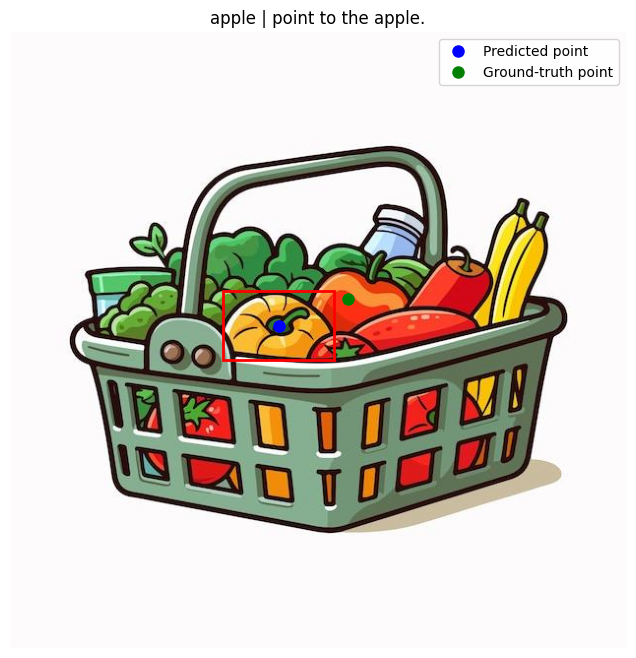

In [12]:
if len(boxes) == 0:
    print("No detections found.")
else:
    best_idx = scores.argmax().item()
    best_box = boxes[best_idx].detach().cpu().numpy()
    best_score = scores[best_idx].item()
    best_text = labels_out[best_idx]

    x1, y1, x2, y2 = best_box
    center_x = (x1 + x2) / 2.0
    center_y = (y1 + y2) / 2.0
    pred_x_norm = (center_x / img_w) * 100.0
    pred_y_norm = (center_y / img_h) * 100.0
    error = math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

    print("Best box:", best_box)
    print("Best score:", best_score)
    print("Matched text:", best_text)
    print("Predicted point (0-100):", (pred_x_norm, pred_y_norm))
    print("Ground-truth point (0-100):", (gt_x, gt_y))
    print("Error:", error)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.plot(center_x, center_y, "bo", markersize=8, label="Predicted point")
    ax.plot(gt_x_px, gt_y_px, "go", markersize=8, label="Ground-truth point")
    ax.legend()
    ax.set_title(f"{label} | {prompt}")
    ax.axis("off")
    plt.show()

## Batch Evaluation Helpers

In [15]:
def get_first_gt_point(sample_row):
    sample_points = sample_row.get("points", [])
    if not sample_points:
        return None
    return float(sample_points[0]["x"]), float(sample_points[0]["y"])

def compute_normalized_error(pred_x_norm, pred_y_norm, gt_x, gt_y):
    dx = pred_x_norm - gt_x
    dy = pred_y_norm - gt_y
    return math.sqrt(dx ** 2 + dy ** 2) / math.sqrt(100.0 ** 2 + 100.0 ** 2)

def run_grounding_dino_on_sample(sample_row, prompt, box_threshold=0.30, text_threshold=0.25):
    filename = os.path.basename(sample_row["image_path"])
    sample_image_path = IMAGES_DIR / filename
    sample_image = Image.open(sample_image_path).convert("RGB")
    sample_w, sample_h = sample_image.size

    gt_point = get_first_gt_point(sample_row)
    if gt_point is None:
        return {
            "id": sample_row["id"],
            "label": sample_row["label"],
            "prompt": prompt,
            "filename": filename,
            "status": "missing_gt",
        }

    gt_x, gt_y = gt_point

    inputs = processor(images=sample_image, text=prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([sample_image.size[::-1]], device=DEVICE)
    processed = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=box_threshold,
        text_threshold=text_threshold,
    )[0]

    boxes = processed["boxes"]
    scores = processed["scores"]
    labels_found = processed["labels"]

    if len(boxes) == 0:
        return {
            "id": sample_row["id"],
            "label": sample_row["label"],
            "prompt": prompt,
            "filename": filename,
            "gt_point": [gt_x, gt_y],
            "pred_point": None,
            "error": None,
            "normalized_error": None,
            "score": None,
            "best_label": None,
            "status": "no_detection",
        }

    best_idx = scores.argmax().item()
    x1, y1, x2, y2 = boxes[best_idx].detach().cpu().numpy()
    center_x = (x1 + x2) / 2.0
    center_y = (y1 + y2) / 2.0
    pred_x_norm = (center_x / sample_w) * 100.0
    pred_y_norm = (center_y / sample_h) * 100.0
    error = math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)
    normalized_error = compute_normalized_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

    return {
        "id": sample_row["id"],
        "label": sample_row["label"],
        "prompt": prompt,
        "filename": filename,
        "gt_point": [gt_x, gt_y],
        "pred_point": [pred_x_norm, pred_y_norm],
        "error": error,
        "normalized_error": normalized_error,
        "score": float(scores[best_idx].item()),
        "best_label": labels_found[best_idx],
        "status": "ok",
    }

## Evaluation Setup

In [37]:
prompt_templates = [
    "{label}.",
    "point to the {label}.",
    "point to where you would grasp this {label}.",
    "grasp the {label}.",
    "hold the {label}.",
    "pick up the {label}.",
]

RUN_FULL_SPLIT = True  # switched to run full validation (may be slow on CPU)
MAX_SAMPLES = 5  # small quick test
SUCCESS_RADIUS = 10.0
SEED = 42
random.seed(SEED)

if RUN_FULL_SPLIT:
    subset = pointing_samples
else:
    subset = pointing_samples[:MAX_SAMPLES]

print("Split:", SPLIT_NAME)
print("Prompt templates:", prompt_templates)
print("Pointing samples available:", len(pointing_samples))
print("Samples selected for evaluation:", len(subset))
print()
print('Subset samples (index, id, label, filename):')
for i, r in enumerate(subset):
    print(i, r.get('id'), r.get('label'), os.path.basename(r.get('image_path')))
print("Run full split:", RUN_FULL_SPLIT)
print("Success radius:", SUCCESS_RADIUS)


Split: val
Prompt templates: ['{label}.', 'point to the {label}.', 'point to where you would grasp this {label}.', 'grasp the {label}.', 'hold the {label}.', 'pick up the {label}.']
Pointing samples available: 183
Samples selected for evaluation: 183

Subset samples (index, id, label, filename):
0 403 apple apple_2.jpg
1 413 apple apple_12.jpg
2 404 apple apple_3.jpg
3 418 apple apple_17.jpg
4 4 backpack backpack_5.jpg
5 9 backpack backpack_10.jpg
6 15 backpack backpack_16.jpg
7 7 backpack backpack_8.jpg
8 36 bag bag_17.jpg
9 27 bag bag_8.jpg
10 37 bag bag_18.jpg
11 21 bag bag_2.jpg
12 760 basket basket_19.jpg
13 745 basket basket_4.jpg
14 755 basket basket_14.jpg
15 761 basket basket_20.jpg
16 426 book book_5.jpg
17 428 book book_7.jpg
18 438 book book_17.jpg
19 440 book book_19.jpg
20 449 bottle bottle_8.jpg
21 459 bottle bottle_18.jpg
22 458 bottle bottle_17.jpg
23 457 bottle bottle_16.jpg
24 480 bowl bowl_19.jpg
25 479 bowl bowl_18.jpg
26 475 bowl bowl_14.jpg
27 463 bowl bowl_2.jpg

## Run Prompt Evaluation

In [38]:
all_results = []

for template in prompt_templates:
    template_results = []
    print("\n" + "=" * 50)
    print("Template:", template)
    print("=" * 50)

    for sample_row in subset:
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        template_results.append(row)
        print(row)

    valid_errors = [row["error"] for row in template_results if row["error"] is not None]
    valid_norm_errors = [row.get("normalized_error") for row in template_results if row.get("normalized_error") is not None]
    success_count = sum(1 for row in template_results if row.get("error") is not None and row["error"] <= SUCCESS_RADIUS)
    detection_count = sum(1 for row in template_results if row["status"] == "ok")
    mean_error = sum(valid_errors) / len(valid_errors) if valid_errors else None
    mean_norm_error = sum(valid_norm_errors) / len(valid_norm_errors) if valid_norm_errors else None
    success_rate = success_count / len(template_results) if template_results else None
    detection_rate = detection_count / len(template_results) if template_results else None
    print("Mean error:", mean_error)
    print("Mean normalized error:", mean_norm_error)
    print("Success rate:", success_rate)
    print("Detection rate:", detection_rate)

    all_results.append({
        "template": template,
        "mean_error": mean_error,
        "mean_normalized_error": mean_norm_error,
        "success_rate": success_rate,
        "detection_rate": detection_rate,
        "details": template_results,
    })


Template: {label}.
{'id': 403, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_2.jpg', 'gt_point': [54.82142857142858, 43.214285714285715], 'pred_point': [np.float32(43.57464), np.float32(47.61673)], 'error': 12.077740938266352, 'normalized_error': 0.08540252518862512, 'score': 0.38158267736434937, 'best_label': 'apple', 'status': 'ok'}
{'id': 413, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_12.jpg', 'gt_point': [75.95238095238095, 62.897290063566416], 'pred_point': [np.float32(47.547016), np.float32(43.86704)], 'error': 34.19086156633725, 'normalized_error': 0.2417659006816757, 'score': 0.3974967300891876, 'best_label': 'apple', 'status': 'ok'}
{'id': 404, 'label': 'apple', 'prompt': 'apple.', 'filename': 'apple_3.jpg', 'gt_point': [2.547703810881462, 91.27682847860167], 'pred_point': [np.float32(2.1649892), np.float32(91.092125)], 'error': 0.42495233885604733, 'normalized_error': 0.0030048668048619463, 'score': 0.7014579772949219, 'best_label': 'apple', 'status

In [39]:
def summarize_template_results(template_result):
    rows = template_result["details"]
    valid_rows = [row for row in rows if row.get("error") is not None]
    category_summary = []

    for label_name in sorted({row["label"] for row in rows}):
        label_rows = [row for row in rows if row["label"] == label_name]
        label_valid = [row for row in label_rows if row.get("error") is not None]
        mean_error = sum(row["error"] for row in label_valid) / len(label_valid) if label_valid else None
        mean_normalized_error = (
            sum(row["normalized_error"] for row in label_valid) / len(label_valid)
            if label_valid else None
        )
        success_rate = (
            sum(1 for row in label_rows if row.get("error") is not None and row["error"] <= SUCCESS_RADIUS) / len(label_rows)
            if label_rows else None
        )
        detection_rate = (
            sum(1 for row in label_rows if row["status"] == "ok") / len(label_rows)
            if label_rows else None
        )
        category_summary.append({
            "label": label_name,
            "num_samples": len(label_rows),
            "num_valid": len(label_valid),
            "mean_error": mean_error,
            "mean_normalized_error": mean_normalized_error,
            "success_rate": success_rate,
            "detection_rate": detection_rate,
        })

    category_summary = sorted(
        category_summary,
        key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
    )

    return {
        "template": template_result["template"],
        "overall": {
            "mean_error": template_result["mean_error"],
            "mean_normalized_error": template_result["mean_normalized_error"],
            "success_rate": template_result["success_rate"],
            "detection_rate": template_result["detection_rate"],
            "num_rows": len(rows),
            "num_valid": len(valid_rows),
        },
        "per_category": category_summary,
    }

expanded_results = [summarize_template_results(item) for item in all_results]
expanded_results[0]

{'template': '{label}.',
 'overall': {'mean_error': 19.464489673716596,
  'mean_normalized_error': 0.13763472640620533,
  'success_rate': 0.4207650273224044,
  'detection_rate': 0.8633879781420765,
  'num_rows': 183,
  'num_valid': 158},
 'per_category': [{'label': 'watch',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 1.057093245876584,
   'mean_normalized_error': 0.00747477802505831,
   'success_rate': 1.0,
   'detection_rate': 1.0},
  {'label': 'mouse',
   'num_samples': 4,
   'num_valid': 3,
   'mean_error': 1.1103102268975282,
   'mean_normalized_error': 0.007851078906600162,
   'success_rate': 0.75,
   'detection_rate': 0.75},
  {'label': 'kettle',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 1.8143465512373398,
   'mean_normalized_error': 0.012829367498023487,
   'success_rate': 1.0,
   'detection_rate': 1.0},
  {'label': 'pen',
   'num_samples': 4,
   'num_valid': 4,
   'mean_error': 2.9609278366604608,
   'mean_normalized_error': 0.02093692151906626,
   

In [40]:
summary_rows = []
for item in expanded_results:
    summary_rows.append({
        "template": item["template"],
        "mean_error": item["overall"]["mean_error"],
        "mean_normalized_error": item["overall"]["mean_normalized_error"],
        "success_rate": item["overall"]["success_rate"],
        "detection_rate": item["overall"]["detection_rate"],
        "num_samples": item["overall"]["num_rows"],
        "num_valid": item["overall"]["num_valid"],
    })

summary_rows = sorted(
    summary_rows,
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)
summary_rows

[{'template': 'point to the {label}.',
  'mean_error': 18.776363462230083,
  'mean_normalized_error': 0.13276893930166214,
  'success_rate': 0.4371584699453552,
  'detection_rate': 0.9180327868852459,
  'num_samples': 183,
  'num_valid': 168},
 {'template': 'grasp the {label}.',
  'mean_error': 19.245374117033283,
  'mean_normalized_error': 0.136085345446263,
  'success_rate': 0.4644808743169399,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': '{label}.',
  'mean_error': 19.464489673716596,
  'mean_normalized_error': 0.13763472640620533,
  'success_rate': 0.4207650273224044,
  'detection_rate': 0.8633879781420765,
  'num_samples': 183,
  'num_valid': 158},
 {'template': 'hold the {label}.',
  'mean_error': 20.013635368929766,
  'mean_normalized_error': 0.14151777285565167,
  'success_rate': 0.44808743169398907,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': 'point to where you would grasp

In [41]:
BEST_TEMPLATE = summary_rows[0]["template"]
best_template_result = next(item for item in expanded_results if item["template"] == BEST_TEMPLATE)
best_template_result["per_category"][:10]

[{'label': 'mouse',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 1.103562204311786,
  'mean_normalized_error': 0.007803363181300382,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'watch',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 1.1636735004776062,
  'mean_normalized_error': 0.008228414232748024,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'pen',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 3.750865669257742,
  'mean_normalized_error': 0.026522625500519672,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'keyboard',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 4.9134041829926955,
  'mean_normalized_error': 0.03474301416504483,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'knife',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 5.002956310437503,
  'mean_normalized_error': 0.03537624333090389,
  'success_rate': 0.75,
  'detection_rate': 1.0},
 {'label': 'remote',
  'num_samples':

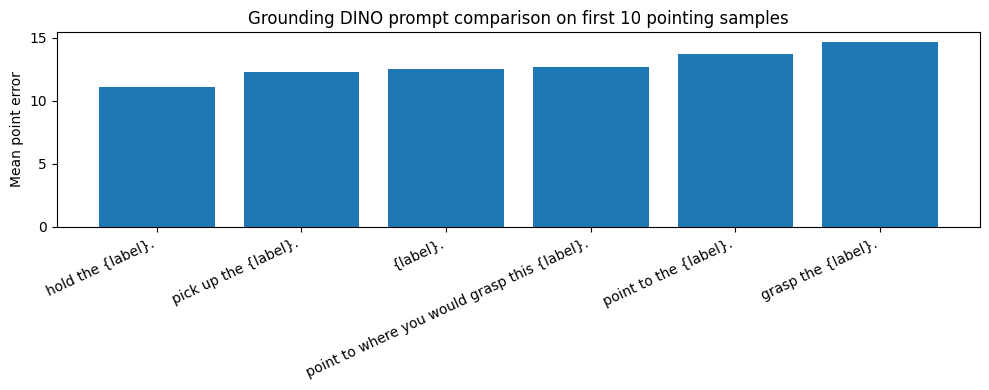

In [33]:
templates = [row["template"] for row in summary_rows]
mean_errors = [row["mean_error"] if row["mean_error"] is not None else float("nan") for row in summary_rows]

plt.figure(figsize=(10, 4))
plt.bar(range(len(templates)), mean_errors)
plt.xticks(range(len(templates)), templates, rotation=25, ha="right")
plt.ylabel("Mean point error")
plt.title(f"Grounding DINO evaluation on {SPLIT_NAME} split")
plt.tight_layout()
plt.show()

## Per-Category View for Best Prompt

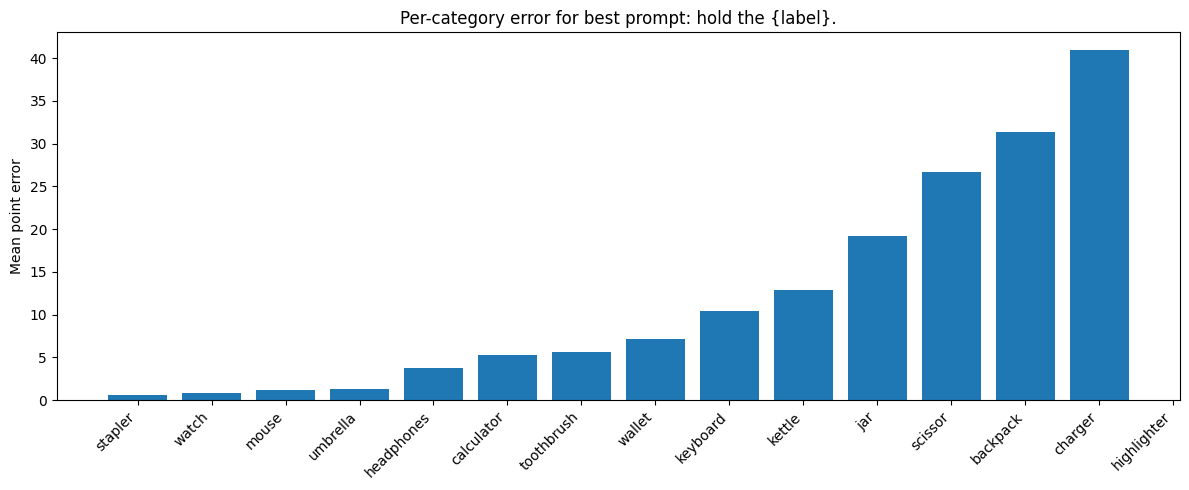

In [34]:
category_rows = best_template_result["per_category"]
cat_labels = [row["label"] for row in category_rows]
cat_errors = [row["mean_error"] if row["mean_error"] is not None else float("nan") for row in category_rows]

plt.figure(figsize=(12, 5))
plt.bar(range(len(cat_labels)), cat_errors)
plt.xticks(range(len(cat_labels)), cat_labels, rotation=45, ha="right")
plt.ylabel("Mean point error")
plt.title(f"Per-category error for best prompt: {BEST_TEMPLATE}")
plt.tight_layout()
plt.show()

## Qualitative Prompt Comparison

c:\Users\bhara\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\grounding_dino\processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


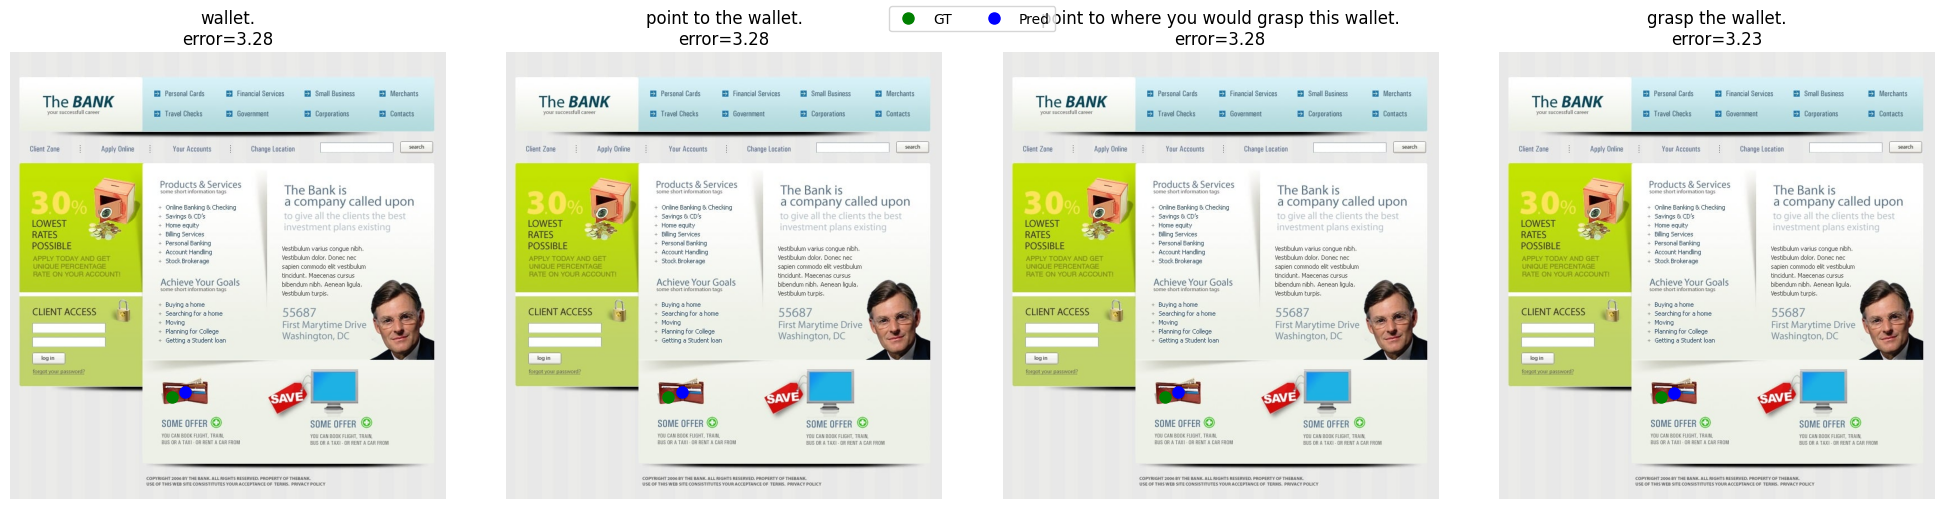

In [35]:
def visualize_prompt_comparison(sample_row, templates_to_show=None):
    if templates_to_show is None:
        templates_to_show = prompt_templates[:4]

    filename = os.path.basename(sample_row["image_path"])
    sample_image = Image.open(IMAGES_DIR / filename).convert("RGB")
    sample_w, sample_h = sample_image.size
    gt_x, gt_y = get_first_gt_point(sample_row)
    gt_x_px = (gt_x / 100.0) * sample_w
    gt_y_px = (gt_y / 100.0) * sample_h

    fig, axes = plt.subplots(1, len(templates_to_show), figsize=(5 * len(templates_to_show), 5))
    if len(templates_to_show) == 1:
        axes = [axes]

    for ax, template in zip(axes, templates_to_show):
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        ax.imshow(sample_image)
        ax.plot(gt_x_px, gt_y_px, "go", markersize=8, label="GT")

        if row["pred_point"] is not None:
            pred_x_px = (row["pred_point"][0] / 100.0) * sample_w
            pred_y_px = (row["pred_point"][1] / 100.0) * sample_h
            ax.plot(pred_x_px, pred_y_px, "bo", markersize=8, label="Pred")
            ax.set_title(f"{prompt}\nerror={row['error']:.2f}")
        else:
            ax.set_title(f"{prompt}\nno detection")

        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
    plt.tight_layout()
    plt.show()

QUAL_SAMPLE_INDEX = 0
visualize_prompt_comparison(pointing_samples[QUAL_SAMPLE_INDEX])

## Save Results

In [22]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(key): make_json_safe(value) for key, value in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(item) for item in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(item) for item in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except Exception:
            pass
    if isinstance(obj, float) and math.isnan(obj):
        return None
    return obj

In [23]:
results_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_prompt_eval.json"
summary_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_prompt_summary.json"
per_category_path = OUTPUT_DIR / f"grounding_dino_{SPLIT_NAME}_final_per_category.json"

safe_all_results = make_json_safe(all_results)
safe_summary_rows = make_json_safe(summary_rows)
safe_best_template_result = make_json_safe(best_template_result)

with open(results_path, "w", encoding="utf-8") as f:
    json.dump(safe_all_results, f, indent=2)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(safe_summary_rows, f, indent=2)

with open(per_category_path, "w", encoding="utf-8") as f:
    json.dump(safe_best_template_result, f, indent=2)

print("Saved detailed results to:", results_path)
print("Saved summary to:", summary_path)
print("Saved best-prompt per-category results to:", per_category_path)

Saved detailed results to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_val_prompt_eval.json
Saved summary to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_val_prompt_summary.json
Saved best-prompt per-category results to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_val_final_per_category.json


## Final Test Evaluation

This section runs the final Grounding DINO evaluation on the `test` split using the best validation prompt.

In [ ]:
FINAL_TEST_SPLIT = "test"
FINAL_TEST_SUCCESS_RADIUS = 10.0

# Pick the final test prompt from validation instead of hardcoding it.
if "summary_rows" in globals() and summary_rows:
    FINAL_TEST_PROMPT_TEMPLATE = summary_rows[0]["template"]
else:
    val_final_summary_path = OUTPUT_DIR / "grounding_dino_val_final_summary.json"
    with open(val_final_summary_path, "r", encoding="utf-8") as f:
        val_final_summary = json.load(f)
    FINAL_TEST_PROMPT_TEMPLATE = val_final_summary["best_prompt"]

final_test_split_path = SPLITS_DIR / f"{FINAL_TEST_SPLIT}.json"
with open(final_test_split_path, "r", encoding="utf-8") as f:
    final_test_data = json.load(f)

final_test_pointing_samples = [
    row for row in final_test_data
    if row.get("collection_method") == "pointing"
]

print("FINAL_TEST_SPLIT:", FINAL_TEST_SPLIT)
print("FINAL_TEST_PROMPT_TEMPLATE:", FINAL_TEST_PROMPT_TEMPLATE)
print("Pointing samples in test split:", len(final_test_pointing_samples))


In [49]:
final_test_rows = []

for sample_row in final_test_pointing_samples:
    prompt = FINAL_TEST_PROMPT_TEMPLATE.format(label=sample_row["label"])
    row = run_grounding_dino_on_sample(sample_row, prompt)
    final_test_rows.append(row)

final_test_valid_rows = [row for row in final_test_rows if row.get("error") is not None]
final_test_mean_error = (
    sum(row["error"] for row in final_test_valid_rows) / len(final_test_valid_rows)
    if final_test_valid_rows else None
)
final_test_mean_normalized_error = (
    sum(row["normalized_error"] for row in final_test_valid_rows) / len(final_test_valid_rows)
    if final_test_valid_rows else None
)
final_test_success_rate = (
    sum(1 for row in final_test_rows if row.get("error") is not None and row["error"] <= FINAL_TEST_SUCCESS_RADIUS) / len(final_test_rows)
    if final_test_rows else None
)
final_test_detection_rate = (
    sum(1 for row in final_test_rows if row["status"] == "ok") / len(final_test_rows)
    if final_test_rows else None
)

final_test_summary = {
    "split": FINAL_TEST_SPLIT,
    "prompt_template": FINAL_TEST_PROMPT_TEMPLATE,
    "num_samples": len(final_test_rows),
    "num_valid": len(final_test_valid_rows),
    "mean_error": final_test_mean_error,
    "mean_normalized_error": final_test_mean_normalized_error,
    "success_rate": final_test_success_rate,
    "detection_rate": final_test_detection_rate,
}

final_test_summary

{'split': 'test',
 'prompt_template': 'point to the {label}.,
 'num_samples': 183,
 'num_valid': 178,
 'mean_error': 17.26408599005799,
 'mean_normalized_error': 0.12207552274557676,
 'success_rate': 0.4918032786885246,
 'detection_rate': 0.9726775956284153}

In [50]:
final_test_per_category = []

for label_name in sorted({row["label"] for row in final_test_rows}):
    label_rows = [row for row in final_test_rows if row["label"] == label_name]
    label_valid = [row for row in label_rows if row.get("error") is not None]
    final_test_per_category.append({
        "label": label_name,
        "num_samples": len(label_rows),
        "num_valid": len(label_valid),
        "mean_error": sum(row["error"] for row in label_valid) / len(label_valid) if label_valid else None,
        "mean_normalized_error": sum(row["normalized_error"] for row in label_valid) / len(label_valid) if label_valid else None,
        "success_rate": (
            sum(1 for row in label_rows if row.get("error") is not None and row["error"] <= FINAL_TEST_SUCCESS_RADIUS) / len(label_rows)
            if label_rows else None
        ),
        "detection_rate": (
            sum(1 for row in label_rows if row["status"] == "ok") / len(label_rows)
            if label_rows else None
        ),
    })

final_test_per_category = sorted(
    final_test_per_category,
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)

final_test_per_category[:10]

[{'label': 'remote',
  'num_samples': 4,
  'num_valid': 3,
  'mean_error': 1.1141762109339386,
  'mean_normalized_error': 0.007878415541881212,
  'success_rate': 0.75,
  'detection_rate': 0.75},
 {'label': 'headphones',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 4.223871991805784,
  'mean_normalized_error': 0.02986728528269799,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'egg',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 4.7814901186814565,
  'mean_normalized_error': 0.033810240870961274,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'bottle',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 4.877304242014337,
  'mean_normalized_error': 0.034487749034382516,
  'success_rate': 1.0,
  'detection_rate': 1.0},
 {'label': 'laptop',
  'num_samples': 4,
  'num_valid': 4,
  'mean_error': 6.378267333941304,
  'mean_normalized_error': 0.045101160840505375,
  'success_rate': 0.5,
  'detection_rate': 1.0},
 {'label': 'backpack',
  'num_sample

In [51]:
final_test_summary_path = OUTPUT_DIR / "grounding_dino_test_raw_summary.json"
final_test_details_path = OUTPUT_DIR / "grounding_dino_test_raw_details.json"
final_test_per_category_path = OUTPUT_DIR / "grounding_dino_test_final_per_category.json"

with open(final_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_summary), f, indent=2)

with open(final_test_details_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_rows), f, indent=2)

with open(final_test_per_category_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_test_per_category), f, indent=2)

print("Saved raw test summary to:", final_test_summary_path)
print("Saved raw test details to:", final_test_details_path)
print("Saved final test per-category results to:", final_test_per_category_path)

Saved raw test summary to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_test_raw_summary.json
Saved raw test details to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_test_raw_details.json
Saved final test per-category results to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_test_final_per_category.json


## Export Flat Result Format

This exports a flatter JSON format. Per-image records keep only per-sample values. Aggregate values such as per-category error and per-prompt error are exported in a separate summary file.

In [43]:
def build_flat_sample_records(rows, split_name, success_radius, best_prompt_name=None):
    flat_records = []
    for row in rows:
        gt_x = row["gt_point"][0] if row.get("gt_point") is not None else None
        gt_y = row["gt_point"][1] if row.get("gt_point") is not None else None
        pred_x = row["pred_point"][0] if row.get("pred_point") is not None else None
        pred_y = row["pred_point"][1] if row.get("pred_point") is not None else None
        pixel_error = row.get("error")
        normalized_pixel_error = row.get("normalized_error")
        success = None if pixel_error is None else int(pixel_error <= success_radius)

        flat_records.append({
            "split": split_name,
            "image_path": str(IMAGES_DIR / row["filename"]),
            "label": row["label"],
            "prompt": row.get("prompt"),
            "pred_x": pred_x,
            "pred_y": pred_y,
            "gt_x": gt_x,
            "gt_y": gt_y,
            "pixel_error": pixel_error,
            "normalized_pixel_error": normalized_pixel_error,
            "success": success,
            "status": row.get("status"),
            "score": row.get("score"),
            "best_label": row.get("best_label"),
            "best_prompt_from_val": best_prompt_name,
            "prompt_sensitivity": None,
            "prompt_consistency": None,
        })
    return flat_records

In [ ]:
val_best_prompt_name = summary_rows[0]["template"] if "summary_rows" in globals() and summary_rows else None
val_best_prompt_rows = []
if "all_results" in globals() and val_best_prompt_name is not None:
    val_best_prompt_rows = next(item["details"] for item in all_results if item["template"] == val_best_prompt_name)

flat_val_records = build_flat_sample_records(
    val_best_prompt_rows,
    split_name="val",
    success_radius=SUCCESS_RADIUS,
    best_prompt_name=val_best_prompt_name,
)

# Compute prompt-level metrics: sensitivity (stddev of per-prompt mean error) and consistency (avg fraction of prompts that succeed per sample)
from statistics import pstdev, mean
# collect mean errors per prompt (exclude None)
prompt_mean_errors = [r['mean_error'] for r in summary_rows if r.get('mean_error') is not None]
prompt_sensitivity = float(pstdev(prompt_mean_errors)) if len(prompt_mean_errors) > 0 else None

# compute per-sample success counts across all prompts
sample_success_counts = {}
all_sample_ids = set()
num_prompts = len(all_results)
for templ in all_results:
    for row in templ['details']:
        sid = row['id']
        all_sample_ids.add(sid)
        ok = 1 if (row.get('error') is not None and row.get('error') <= SUCCESS_RADIUS) else 0
        sample_success_counts[sid] = sample_success_counts.get(sid, 0) + ok

per_sample_consistency = {sid: (sample_success_counts.get(sid, 0) / num_prompts) for sid in all_sample_ids}
prompt_consistency = float(mean(per_sample_consistency.values())) if per_sample_consistency else None

# attach prompt metrics to flat records: per-image prompt_consistency (per-sample fraction) and global prompt_sensitivity
id_to_consistency = per_sample_consistency
for rec in flat_val_records:
    sid = None
    # try to get id from filename by matching against pointing_samples
    for s in pointing_samples:
        if os.path.basename(s['image_path']) == os.path.basename(rec['image_path']):
            sid = s.get('id')
            break
    rec['prompt_sensitivity'] = prompt_sensitivity
    rec['prompt_consistency'] = id_to_consistency.get(sid, None) if sid is not None else None

flat_val_summary = {
    "split": "val",
    "best_prompt": val_best_prompt_name,
    "success_rate": next((row["success_rate"] for row in summary_rows if row["template"] == val_best_prompt_name), None),
    "per_prompt_error": {row["template"]: row["mean_error"] for row in summary_rows},
    "per_category_error": {row["label"]: row["mean_error"] for row in best_template_result["per_category"]},
    "prompt_sensitivity": prompt_sensitivity,
    "prompt_consistency": prompt_consistency,
    "per_prompt_normalized_error": {row["template"]: row["mean_normalized_error"] for row in summary_rows},
    "per_prompt_success_rate": {row["template"]: row["success_rate"] for row in summary_rows},
    "per_prompt_detection_rate": {row["template"]: row["detection_rate"] for row in summary_rows},
}

flat_val_path = OUTPUT_DIR / "grounding_dino_val_final_per_image.json"
flat_val_summary_path = OUTPUT_DIR / "grounding_dino_val_final_summary.json"

with open(flat_val_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_val_records), f, indent=2)

with open(flat_val_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_val_summary), f, indent=2)

print("Saved final val records to:", flat_val_path)
print("Saved final val summary to:", flat_val_summary_path)
flat_val_summary


In [61]:
flat_test_records = build_flat_sample_records(
    final_test_rows,
    split_name="test",
    success_radius=FINAL_TEST_SUCCESS_RADIUS,
    best_prompt_name=FINAL_TEST_PROMPT_TEMPLATE,
)

flat_test_summary = {
    "split": "test",
    "best_prompt": FINAL_TEST_PROMPT_TEMPLATE,
    "success_rate": final_test_summary["success_rate"],
    "per_prompt_error": {FINAL_TEST_PROMPT_TEMPLATE: final_test_summary["mean_error"]},
    "per_category_error": {row["label"]: row["mean_error"] for row in final_test_per_category},
    "prompt_sensitivity": prompt_sensitivity,
    "prompt_consistency": prompt_consistency,
}

flat_test_path = OUTPUT_DIR / "grounding_dino_test_final_per_image.json"
flat_test_summary_path = OUTPUT_DIR / "grounding_dino_test_final_summary.json"

with open(flat_test_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_test_records), f, indent=2)

with open(flat_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(flat_test_summary), f, indent=2)

print("Saved final test records to:", flat_test_path)
print("Saved final test summary to:", flat_test_summary_path)
flat_test_records[:2]

Saved final test records to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_test_final_per_image.json
Saved final test summary to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\grounding_dino_test_final_summary.json


[{'split': 'test',
  'image_path': 'c:\\UW_PROJECTS\\Grasp Point Prediction-20260411T191616Z-3-001\\Grasp Point Prediction\\data\\pixmo_subset_v3\\pixmo_subset_v3\\images\\apple_8.jpg',
  'label': 'apple',
  'prompt': 'hold the apple.',
  'pred_x': np.float32(72.49631),
  'pred_y': np.float32(79.41822),
  'gt_x': 32.976190476190474,
  'gt_y': 55.833333333333336,
  'pixel_error': 46.02267825825112,
  'normalized_pixel_error': 0.3254294788477605,
  'success': 0,
  'status': 'ok',
  'score': 0.3571700155735016,
  'best_label': 'the apple',
  'best_prompt_from_val': 'point to the {label}.',
  'prompt_sensitivity': None,
  'prompt_consistency': None},
 {'split': 'test',
  'image_path': 'c:\\UW_PROJECTS\\Grasp Point Prediction-20260411T191616Z-3-001\\Grasp Point Prediction\\data\\pixmo_subset_v3\\pixmo_subset_v3\\images\\apple_9.jpg',
  'label': 'apple',
  'prompt': 'hold the apple.',
  'pred_x': np.float32(72.49631),
  'pred_y': np.float32(79.41822),
  'gt_x': 24.404761904761905,
  'gt_y': 



Dataset statistics moved earlier in the notebook (see Project Paths cell).

## Baseline: DINO feature extraction + CPU regressor
This section extracts Grounding DINO detections (box centers, sizes, scores, predicted label) for the `train`, `val`, and `test` splits, trains a lightweight CPU-friendly regressor to predict the GT pointing offset from the detected box center, and evaluates on `val` and `test`.

Diagnostics file not found, computing on-the-fly: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\diagnostics_sample_4_topk.json


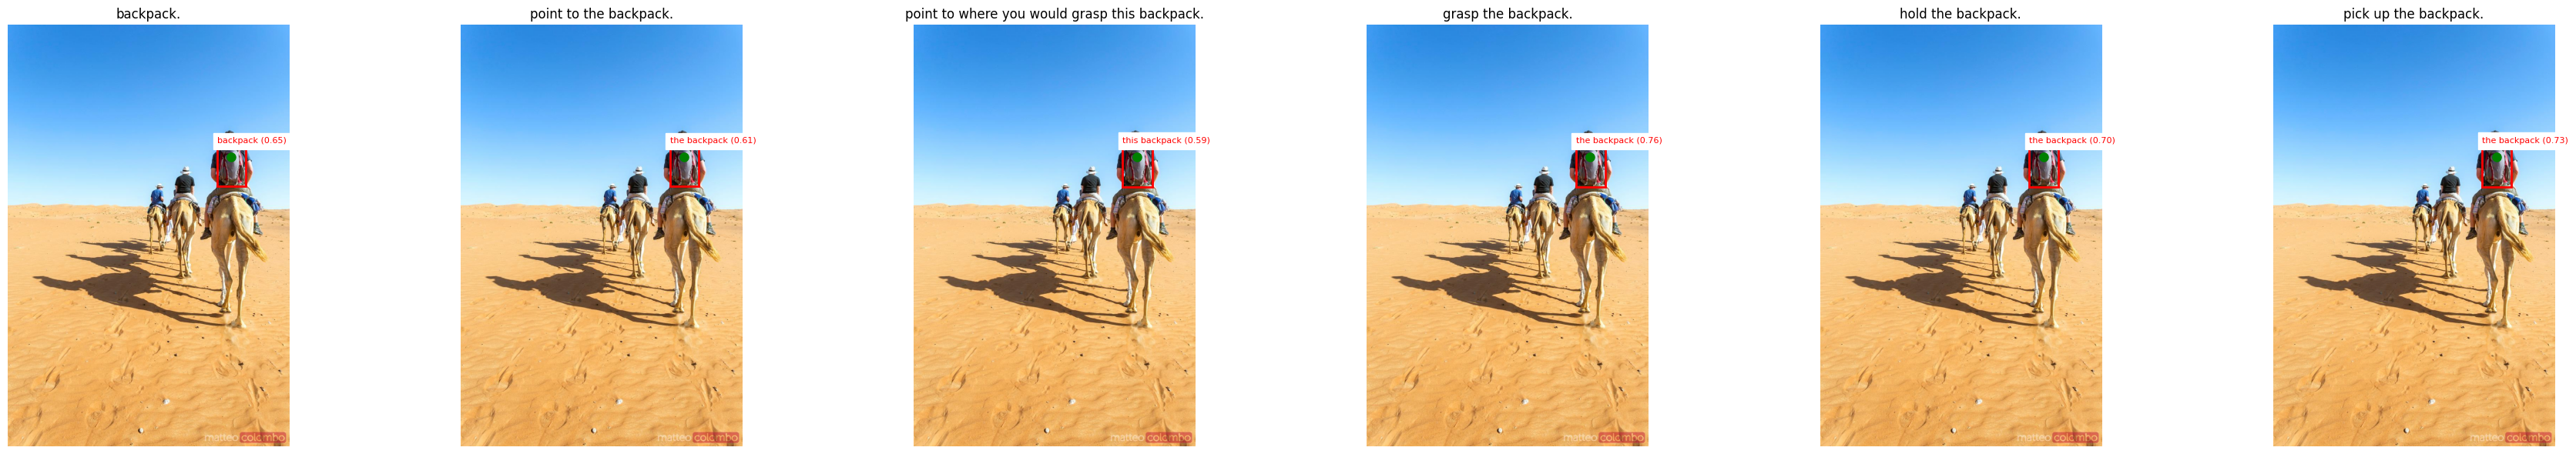

Diagnostics saved to: c:\UW_PROJECTS\Grasp Point Prediction-20260411T191616Z-3-001\Grasp Point Prediction\outputs\grounding_dino_from_scratch\diagnostics_sample_4_topk.json


In [35]:
# Visualize diagnostics for a selected sample (by id or index).
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Select sample: optionally set SAMPLE_ID (int) or SAMPLE_INDEX (int). If both unset, pick first non-apple sample.
SAMPLE_ID = None  # e.g. 9 (leave None to auto-select)
SAMPLE_INDEX = None  # leave None to auto-select first non-apple sample
TOPK = 5

# auto-select a non-apple sample if neither SAMPLE_ID nor SAMPLE_INDEX provided
if SAMPLE_ID is None and SAMPLE_INDEX is None:
    SAMPLE_INDEX = next((i for i, r in enumerate(pointing_samples) if r.get('label') != 'apple'), 0)

if 'pointing_samples' not in globals():
    raise RuntimeError('pointing_samples not found — run the Load One Split cell first')

# locate the sample row
sample_row = None
if SAMPLE_ID is not None:
    for r in pointing_samples:
        if r.get('id') == SAMPLE_ID:
            sample_row = r
            break
else:
    if SAMPLE_INDEX < 0 or SAMPLE_INDEX >= len(pointing_samples):
        raise IndexError('SAMPLE_INDEX out of range')
    sample_row = pointing_samples[SAMPLE_INDEX]

sample_id = sample_row.get('id')
filename = os.path.basename(sample_row['image_path'])

diag_path = OUTPUT_DIR / f'diagnostics_sample_{sample_id}_topk.json' if 'OUTPUT_DIR' in globals() else Path(f'outputs/grounding_dino_from_scratch/diagnostics_sample_{sample_id}_topk.json')

def safe_label(x):
    try:
        import torch
        if hasattr(x, 'detach'):
            v = x.detach().cpu().numpy()
            if v.shape == ():
                return str(v.item())
            return str(v.tolist())
        return str(x)
    except Exception:
        return str(x)

if not diag_path.exists():
    print('Diagnostics file not found, computing on-the-fly:', diag_path)
    sample_image = Image.open(IMAGES_DIR / filename).convert('RGB')
    prompts = []
    for tmpl in prompt_templates:
        prompt = tmpl.format(label=sample_row['label'])
        inputs = processor(images=sample_image, text=prompt, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)
        target_sizes = torch.tensor([sample_image.size[::-1]], device=DEVICE)
        processed = processor.post_process_grounded_object_detection(outputs, inputs.input_ids, target_sizes=target_sizes, threshold=0.30, text_threshold=0.25)[0]
        boxes = processed.get('boxes', [])
        scores = processed.get('scores', [])
        labels_found = processed.get('labels', [])
        dets = []
        for i in range(min(TOPK, len(boxes))):
            b = boxes[i]
            if hasattr(b, 'detach'):
                b = b.detach().cpu().numpy().tolist()
            else:
                b = [float(x) for x in b]
            s = float(scores[i].item()) if hasattr(scores[i], 'item') else float(scores[i])
            lab = safe_label(labels_found[i]) if i < len(labels_found) else ''
            dets.append({'box': [float(b[0]), float(b[1]), float(b[2]), float(b[3])], 'score': s, 'label': lab})
        prompts.append({'prompt': prompt, 'detections': dets})

    diag = {'id': sample_id, 'filename': str(IMAGES_DIR / filename), 'prompts': prompts, 'gt_point': get_first_gt_point(sample_row)}
    diag_path.parent.mkdir(parents=True, exist_ok=True)
    with open(diag_path, 'w', encoding='utf-8') as f:
        json.dump(make_json_safe(diag), f, indent=2)
else:
    print('Loading diagnostics from:', diag_path)
    with open(diag_path, 'r', encoding='utf-8') as f:
        diag = json.load(f)

img = Image.open(diag['filename']).convert('RGB')
w, h = img.size
prompts = diag['prompts']
n = len(prompts)
plt.figure(figsize=(6*n,6))
for i, p in enumerate(prompts, 1):
    ax = plt.subplot(1, n, i)
    ax.imshow(img)
    ax.set_title(p['prompt'])
    for det in p['detections'][:TOPK]:
        x1,y1,x2,y2 = det['box']
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(0,y1-6), f"{det['label']} ({det['score']:.2f})", color='red', fontsize=8, backgroundcolor='white')
    gt = diag.get('gt_point')
    if gt is not None:
        gx = (gt[0]/100.0)*w
        gy = (gt[1]/100.0)*h
        ax.plot(gx, gy, 'go', markersize=8, label='GT')
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Diagnostics saved to:', diag_path)

## Robust Test Prompt Sweep

Recommendation: run all prompts on the test split if you want robust, comparable results. This section compares the best validation prompt against the alternatives and computes prompt sensitivity / consistency inputs per sample.

In [62]:
ROBUST_TEST_SPLIT = "test"
ROBUST_TEST_PROMPT_TEMPLATES = [
    "{label}.",
    "point to the {label}.",
    "point to where you would grasp this {label}.",
    "grasp the {label}.",
    "hold the {label}.",
    "pick up the {label}.",
]
ROBUST_TEST_SUCCESS_RADIUS = 10.0

robust_test_split_path = SPLITS_DIR / f"{ROBUST_TEST_SPLIT}.json"
with open(robust_test_split_path, "r", encoding="utf-8") as f:
    robust_test_data = json.load(f)

robust_test_pointing_samples = [
    row for row in robust_test_data
    if row.get("collection_method") == "pointing"
]

print("ROBUST_TEST_SPLIT:", ROBUST_TEST_SPLIT)
print("Prompt templates:", ROBUST_TEST_PROMPT_TEMPLATES)
print("Pointing samples in robust test split:", len(robust_test_pointing_samples))

ROBUST_TEST_SPLIT: test
Prompt templates: ['{label}.', 'point to the {label}.', 'point to where you would grasp this {label}.', 'grasp the {label}.', 'hold the {label}.', 'pick up the {label}.']
Pointing samples in robust test split: 183


In [65]:
robust_test_all_results = []

for template in ROBUST_TEST_PROMPT_TEMPLATES:
    template_results = []
    for sample_row in robust_test_pointing_samples:
        prompt = template.format(label=sample_row["label"])
        row = run_grounding_dino_on_sample(sample_row, prompt)
        template_results.append(row)

    valid_errors = [row["error"] for row in template_results if row["error"] is not None]
    valid_norm_errors = [row["normalized_error"] for row in template_results if row["normalized_error"] is not None]
    success_count = sum(1 for row in template_results if row.get("error") is not None and row["error"] <= ROBUST_TEST_SUCCESS_RADIUS)
    detection_count = sum(1 for row in template_results if row["status"] == "ok")

    robust_test_all_results.append({
        "template": template,
        "mean_error": sum(valid_errors) / len(valid_errors) if valid_errors else None,
        "mean_normalized_error": sum(valid_norm_errors) / len(valid_norm_errors) if valid_norm_errors else None,
        "success_rate": success_count / len(template_results) if template_results else None,
        "detection_rate": detection_count / len(template_results) if template_results else None,
        "details": template_results,
    })

robust_test_summary_rows = sorted(
    [
        {
            "template": item["template"],
            "mean_error": item["mean_error"],
            "mean_normalized_error": item["mean_normalized_error"],
            "success_rate": item["success_rate"],
            "detection_rate": item["detection_rate"],
            "num_samples": len(item["details"]),
            "num_valid": sum(1 for row in item["details"] if row.get("error") is not None),
        }
        for item in robust_test_all_results
    ],
    key=lambda row: float("inf") if row["mean_error"] is None else row["mean_error"]
)

robust_test_summary_rows

[{'template': 'hold the {label}.',
  'mean_error': 17.26408599005799,
  'mean_normalized_error': 0.12207552274557676,
  'success_rate': 0.4918032786885246,
  'detection_rate': 0.9726775956284153,
  'num_samples': 183,
  'num_valid': 178},
 {'template': 'point to where you would grasp this {label}.',
  'mean_error': 17.474947894596887,
  'mean_normalized_error': 0.1235665415715104,
  'success_rate': 0.4644808743169399,
  'detection_rate': 0.8688524590163934,
  'num_samples': 183,
  'num_valid': 159},
 {'template': 'grasp the {label}.',
  'mean_error': 17.634275489517623,
  'mean_normalized_error': 0.12469315779949636,
  'success_rate': 0.5081967213114754,
  'detection_rate': 0.9836065573770492,
  'num_samples': 183,
  'num_valid': 180},
 {'template': 'pick up the {label}.',
  'mean_error': 17.92467547632865,
  'mean_normalized_error': 0.12674659579880196,
  'success_rate': 0.4918032786885246,
  'detection_rate': 0.9508196721311475,
  'num_samples': 183,
  'num_valid': 174},
 {'template'

In [66]:
def compute_prompt_motion_metrics(result_sets, action_templates=None):
    if action_templates is None:
        action_templates = [
            "grasp the {label}.",
            "hold the {label}.",
            "pick up the {label}.",
        ]

    by_template = {item["template"]: item["details"] for item in result_sets}
    sample_ids = [row["id"] for row in result_sets[0]["details"]]
    sensitivity_map = {}
    consistency_map = {}

    def average_pairwise_distance(points):
        if len(points) < 2:
            return None
        distances = []
        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                dx = points[i][0] - points[j][0]
                dy = points[i][1] - points[j][1]
                distances.append(math.sqrt(dx ** 2 + dy ** 2))
        return sum(distances) / len(distances) if distances else None

    for sample_id in sample_ids:
        points_all = []
        points_action = []
        for template, rows in by_template.items():
            row = next(r for r in rows if r["id"] == sample_id)
            if row.get("pred_point") is not None:
                points_all.append(row["pred_point"])
                if template in action_templates:
                    points_action.append(row["pred_point"])
        sensitivity_map[sample_id] = average_pairwise_distance(points_all)
        consistency_map[sample_id] = average_pairwise_distance(points_action)

    return sensitivity_map, consistency_map

robust_test_prompt_sensitivity_map, robust_test_prompt_consistency_map = compute_prompt_motion_metrics(robust_test_all_results)

robust_test_motion_summary = {
    "prompt_sensitivity_mean": sum(v for v in robust_test_prompt_sensitivity_map.values() if v is not None) / len([v for v in robust_test_prompt_sensitivity_map.values() if v is not None]),
    "prompt_consistency_mean": sum(v for v in robust_test_prompt_consistency_map.values() if v is not None) / len([v for v in robust_test_prompt_consistency_map.values() if v is not None]),
}

robust_test_motion_summary

{'prompt_sensitivity_mean': 4.585238711028545,
 'prompt_consistency_mean': 2.465866751404082}

In [ ]:
robust_test_per_image_records = []

for item in robust_test_all_results:
    for row in item["details"]:
        sample_id = row["id"]
        robust_test_per_image_records.append({
            "split": ROBUST_TEST_SPLIT,
            "template": item["template"],
            "image_path": str(IMAGES_DIR / row["filename"]),
            "label": row["label"],
            "pred_x": row["pred_point"][0] if row.get("pred_point") is not None else None,
            "pred_y": row["pred_point"][1] if row.get("pred_point") is not None else None,
            "gt_x": row["gt_point"][0] if row.get("gt_point") is not None else None,
            "gt_y": row["gt_point"][1] if row.get("gt_point") is not None else None,
            "pixel_error": row.get("error"),
            "normalized_pixel_error": row.get("normalized_error"),
            "success": None if row.get("error") is None else int(row["error"] <= ROBUST_TEST_SUCCESS_RADIUS),
            "status": row.get("status"),
            "score": row.get("score"),
            "best_label": row.get("best_label"),
            "prompt_sensitivity": robust_test_prompt_sensitivity_map.get(sample_id),
            "prompt_consistency": robust_test_prompt_consistency_map.get(sample_id),
        })

robust_test_best_prompt = robust_test_summary_rows[0]["template"] if robust_test_summary_rows else None
robust_test_best_prompt_row = robust_test_summary_rows[0] if robust_test_summary_rows else {}

robust_test_per_prompt_per_category = []
for item in robust_test_all_results:
    robust_test_per_prompt_per_category.append({
        "template": item["template"],
        "per_category": item["per_category"],
    })

robust_test_aggregate_summary = {
    "split": ROBUST_TEST_SPLIT,
    "best_prompt": robust_test_best_prompt,
    "best_template_from_val": BEST_TEMPLATE if "BEST_TEMPLATE" in globals() else None,
    "success_rate": robust_test_best_prompt_row.get("success_rate"),
    "per_prompt_error": {row["template"]: row["mean_error"] for row in robust_test_summary_rows},
    "per_category_error": None,
    "prompt_sensitivity": robust_test_motion_summary["prompt_sensitivity_mean"],
    "prompt_consistency": robust_test_motion_summary["prompt_consistency_mean"],
    "per_prompt_normalized_error": {row["template"]: row["mean_normalized_error"] for row in robust_test_summary_rows},
    "per_prompt_success_rate": {row["template"]: row["success_rate"] for row in robust_test_summary_rows},
    "per_prompt_detection_rate": {row["template"]: row["detection_rate"] for row in robust_test_summary_rows},
}

robust_test_per_image_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_per_image.json"
robust_test_summary_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_aggregate_summary.json"
robust_test_per_category_path = OUTPUT_DIR / "grounding_dino_test_all_prompts_per_category.json"

with open(robust_test_per_image_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_per_image_records), f, indent=2)

with open(robust_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_aggregate_summary), f, indent=2)

with open(robust_test_per_category_path, "w", encoding="utf-8") as f:
    json.dump(make_json_safe(robust_test_per_prompt_per_category), f, indent=2)

print("Saved robust test per-image results to:", robust_test_per_image_path)
print("Saved robust test aggregate summary to:", robust_test_summary_path)
print("Saved robust test per-category results to:", robust_test_per_category_path)
robust_test_summary_rows
